### 2. del naloge (Ko imamo dve elastični konstanti)

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from scipy.interpolate import interp1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import KFold

from DataGeneration import theta_time_evolution

plt.rcParams.update({'font.size': 12})

In [2]:
root = "C:\\Users\\tadej\\Desktop\\STUDIJ\\mag-2.letnik\\PSUF\\PSUF3\\data\\"

dict_hh = {
    'Kvalues' : np.load(root + "DataK13_hh\\Kvalues.npy"),
    'theta0' : np.load(root + "DataK13_hh\\theta0.npy"),
    'I500_n0' : np.load(root + "DataK13_hh\\intensity500noise0.npy"),
    'I500_n100' : np.load(root + "DataK13_hh\\intensity500noise100.npy"),
    'I505_n0' : np.load(root + "DataK13_hh\\intensity505noise0.npy"),
    'I505_n100' : np.load(root + "DataK13_hh\\intensity505noise100.npy"),
    'I700_n0' : np.load(root + "DataK13_hh\\intensity700noise0.npy"),
    'I700_n100' : np.load(root + "DataK13_hh\\intensity700noise100.npy"),
    'I900_n0' : np.load(root + "DataK13_hh\\intensity900noise0.npy"),
    'I900_n100' : np.load(root + "DataK13_hh\\intensity900noise100.npy")
}

dict_ph = {
    'Kvalues' : np.load(root + "DataK13_ph\\Kvalues.npy"),
    'theta0' : np.load(root + "DataK13_ph\\theta0.npy"),
    'I500_n0' : np.load(root + "DataK13_ph\\intensity500noise0.npy"),
    'I500_n100' : np.load(root + "DataK13_ph\\intensity500noise100.npy"),
    'I505_n0' : np.load(root + "DataK13_ph\\intensity505noise0.npy"),
    'I505_n100' : np.load(root + "DataK13_ph\\intensity505noise100.npy"),
    'I700_n0' : np.load(root + "DataK13_ph\\intensity700noise0.npy"),
    'I700_n100' : np.load(root + "DataK13_ph\\intensity700noise100.npy"),
    'I900_n0' : np.load(root + "DataK13_ph\\intensity900noise0.npy"),
    'I900_n100' : np.load(root + "DataK13_ph\\intensity900noise100.npy")
}

dict_pp = {
    'Kvalues' : np.load(root + "DataK13_pp\\Kvalues.npy"),
    'theta0' : np.load(root + "DataK13_pp\\theta0.npy"),
    'I500_n0' : np.load(root + "DataK13_pp\\intensity500noise0.npy"),
    'I500_n100' : np.load(root + "DataK13_pp\\intensity500noise100.npy"),
    'I505_n0' : np.load(root + "DataK13_pp\\intensity505noise0.npy"),
    'I505_n100' : np.load(root + "DataK13_pp\\intensity505noise100.npy"),
    'I700_n0' : np.load(root + "DataK13_pp\\intensity700noise0.npy"),
    'I700_n100' : np.load(root + "DataK13_pp\\intensity700noise100.npy"),
    'I900_n0' : np.load(root + "DataK13_pp\\intensity900noise0.npy"),
    'I900_n100' : np.load(root + "DataK13_pp\\intensity900noise100.npy")
}

In [3]:
D = 10 * 1e-6 # Thicknes of layer in meters
n_z = np.shape(dict_hh['theta0'][0])[0]
zs = np.linspace(0, D, n_z) * 1e6 # in um

T = 5 * 1e-6 * (240000 / 600)**2 # Time in seconds
n_t = np.shape(dict_hh['I500_n0'][0])[0]
ts = np.linspace(0, T, n_t)

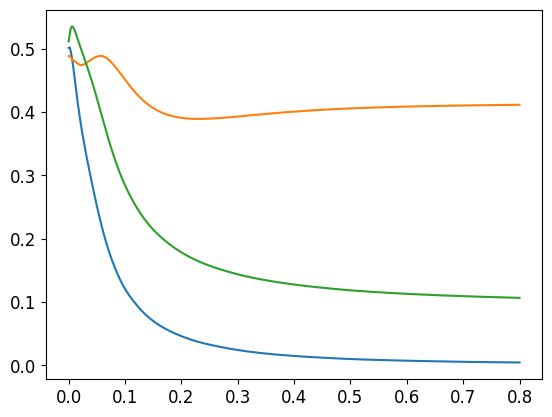

In [6]:
I_hh = dict_hh['I500_n0'][1]

I_hh = np.average(dict_hh['I500_n0'], axis=0)
I_ph = np.average(dict_ph['I500_n0'], axis=0)
I_pp = np.average(dict_pp['I500_n0'], axis=0)

plt.plot(ts, I_hh)
plt.plot(ts, I_ph)
plt.plot(ts, I_pp)

## konstrukcija nevronske mreže

In [4]:
def create_model(hidden_layers, size, activation):
    model = tf.keras.Sequential()

    # Input layer + prva skrita plast
    model.add(tf.keras.layers.Dense(size[0], activation=activation, input_shape=(400,)))

    # Preostale skrite plasti
    for i in range(1, hidden_layers):
        model.add(tf.keras.layers.Dense(size[i], activation=activation))

    # Izhodna plast
    model.add(tf.keras.layers.Dense(2, activation='sigmoid'))

    # Compile
    model.compile(
        optimizer='adam',
        loss='mean_absolute_error',
        metrics=['mean_squared_error']
    )

    return model


def run_KFold(X, Y, hidden_layers, size, activation, save_path="saved_models"):
    
    # ustvari direktorij za shranjevanje modelov
    os.makedirs(save_path, exist_ok=True)

    kf = KFold(n_splits=5)

    scores_MAE = []
    scores_MSE = []
    histories = []
    best_model_paths = []

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    fold = 1
    for train_idx, test_idx in kf.split(X, Y):

        print(f"Training fold {fold}...")

        model = create_model(hidden_layers, size, activation)

        # pot za shranjevanje najboljšega modela
        model_path = os.path.join(save_path, f"best_model_fold_{fold}.keras")

        checkpoint = tf.keras.callbacks.ModelCheckpoint(
            model_path,
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=False,   # shrani cel model (struktura + uteži)
            verbose=0
        )

        history = model.fit(
            X[train_idx], Y[train_idx],
            epochs=200,
            batch_size=100,
            verbose=0,
            validation_split=0.1,
            shuffle=True,
            callbacks=[early_stop, checkpoint]
        )

        histories.append(history)
        best_model_paths.append(model_path)

        # naložimo NAJBOLJŠI model iz datoteke
        best_model = tf.keras.models.load_model(model_path)

        # evaluacija najboljšega modela na testnem setu
        mae, mse = best_model.evaluate(X[test_idx], Y[test_idx], verbose=0)

        scores_MAE.append(mae)
        scores_MSE.append(mse)

        print(f" Fold {fold} → MAE = {mae:.4f}, MSE = {mse:.4f}")
        fold += 1

    # -----------------------------
    # Rezultati
    # -----------------------------
    print("\n============================")
    print("FINAL RESULTS OVER ALL FOLDS")
    print("============================")

    print(f"Average MAE: {np.mean(scores_MAE):.4f} ± {np.std(scores_MAE):.4f}")
    print(f"Average MSE: {np.mean(scores_MSE):.4f} ± {np.std(scores_MSE):.4f}")

    return scores_MAE, scores_MSE, histories


In [ ]:
# Kmax = 20e-12
# sidranje = "pp"
# folder = f"TestNTrain_{sidranje}\\"

# # združi vse I*_n100
# X100 = np.concatenate([dict_pp['I500_n100'], dict_pp['I505_n100'], dict_pp['I700_n100'], dict_pp['I900_n100']], axis=0)
# X = np.concatenate([dict_pp['I500_n0'], dict_pp['I505_n0'], dict_pp['I700_n0'], dict_pp['I900_n0']], axis=0)
# Y = np.concatenate([dict_pp['Kvalues'], dict_pp['Kvalues'], dict_pp['Kvalues'], dict_pp['Kvalues']], axis=0)/Kmax

# # shuffle indeksov
# indices = np.arange(X100.shape[0])
# np.random.shuffle(indices)

# X100 = X100[indices]
# X = X[indices]
# Y = Y[indices]

# # Razdelitev na train/test
# n = X.shape[0]
# nt = int(0.9 * n)

# X100_train = X100[:nt]
# X100_test  = X100[nt:]
# X_train = X[:nt]
# X_test  = X[nt:]

# Y_train = Y[:nt]
# Y_test  = Y[nt:]

# print(X100_train.shape, X100_test.shape, Y_train.shape, Y_test.shape)

# # Shrani podatke
# np.save(root + folder + "X100.npy", X100_train)
# np.save(root + folder + "X100_test.npy", X100_test)
# np.save(root + folder + "X.npy", X_train)
# np.save(root + folder + "X_test.npy", X_test)
# np.save(root + folder + "Y.npy", Y_train)
# np.save(root + folder + "Y_test.npy", Y_test)

(360000, 400) (40000, 400) (360000, 2) (40000, 2)


In [5]:
### --- hh train --- ###

X = np.load(root + "TestNTrain_hh\\X.npy")
X100 = np.load(root + "TestNTrain_hh\\X100.npy")
X_test  = np.load(root + "TestNTrain_hh\\X_test.npy")
X100_test  = np.load(root + "TestNTrain_hh\\X100_test.npy")
Y = np.load(root + "TestNTrain_hh\\Y.npy") # Y so že shranjeni normalizirani!!!
Y_test = np.load(root + "TestNTrain_hh\\Y_test.npy")

hidden_layers = 3
size = [200, 100, 50]
activation = 'relu'
save_path0 = f"models3\\model0_hh"
save_path100 = f"models3\\model100_hh"

MAE0_hh, MSE0_hh, histories0_hh = run_KFold(X, Y, hidden_layers, size, activation, save_path0)
MAE100_hh, MSE100_hh, histories100_hh = run_KFold(X100, Y, hidden_layers, size, activation, save_path100)

Training fold 1...


c:\Users\tadej\Desktop\STUDIJ\mag-2.letnik\PSUF\PSUF-venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

In [37]:
### --- ph train --- ###

X = np.load(root + "TestNTrain_ph\\X.npy")
X100 = np.load(root + "TestNTrain_ph\\X100.npy")
X_test  = np.load(root + "TestNTrain_ph\\X_test.npy")
X100_test  = np.load(root + "TestNTrain_ph\\X100_test.npy")
Y = np.load(root + "TestNTrain_ph\\Y.npy") # Y so že shranjeni normalizirani!!!
Y_test = np.load(root + "TestNTrain_ph\\Y_test.npy")

hidden_layers = 3
size = [200, 100, 50]
activation = 'relu'
save_path0 = f"models3\\model0_ph"
save_path100 = f"models3\\model100_ph"

MAE0_ph, MSE0_ph, histories0_ph = run_KFold(X, Y, hidden_layers, size, activation, save_path0)
MAE100_ph, MSE100_ph, histories100_ph = run_KFold(X100, Y, hidden_layers, size, activation, save_path100)

Training fold 1...


c:\Users\tadej\Desktop\STUDIJ\mag-2.letnik\PSUF\PSUF-venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 Fold 1 → MAE = 0.1204, MSE = 0.0343
Training fold 2...
 Fold 2 → MAE = 0.1397, MSE = 0.0400
Training fold 3...
 Fold 3 → MAE = 0.1420, MSE = 0.0409
Training fold 4...
 Fold 4 → MAE = 0.1414, MSE = 0.0416
Training fold 5...
 Fold 5 → MAE = 0.1438, MSE = 0.0426

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.1375 ± 0.0086
Average MSE: 0.0399 ± 0.0029
Training fold 1...
 Fold 1 → MAE = 0.1577, MSE = 0.0480
Training fold 2...
 Fold 2 → MAE = 0.1620, MSE = 0.0490
Training fold 3...
 Fold 3 → MAE = 0.1607, MSE = 0.0483
Training fold 4...
 Fold 4 → MAE = 0.1606, MSE = 0.0490
Training fold 5...
 Fold 5 → MAE = 0.1629, MSE = 0.0495

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.1608 ± 0.0017
Average MSE: 0.0487 ± 0.0005


In [38]:
### --- pp train --- ###

X = np.load(root + "TestNTrain_pp\\X.npy")
X100 = np.load(root + "TestNTrain_pp\\X100.npy")
X_test  = np.load(root + "TestNTrain_pp\\X_test.npy")
X100_test  = np.load(root + "TestNTrain_pp\\X100_test.npy")
Y = np.load(root + "TestNTrain_pp\\Y.npy") # Y so že shranjeni normalizirani!!!
Y_test = np.load(root + "TestNTrain_pp\\Y_test.npy")

hidden_layers = 3
size = [200, 100, 50]
activation = 'relu'
save_path0 = f"models3\\model0_pp"
save_path100 = f"models3\\model100_pp"

MAE0_pp, MSE0_pp, histories0_pp = run_KFold(X, Y, hidden_layers, size, activation, save_path0)
MAE100_pp, MSE100_pp, histories100_pp = run_KFold(X100, Y, hidden_layers, size, activation, save_path100)

Training fold 1...
 Fold 1 → MAE = 0.1092, MSE = 0.0313
Training fold 2...
 Fold 2 → MAE = 0.1318, MSE = 0.0373
Training fold 3...
 Fold 3 → MAE = 0.1306, MSE = 0.0383
Training fold 4...
 Fold 4 → MAE = 0.1274, MSE = 0.0369
Training fold 5...
 Fold 5 → MAE = 0.1274, MSE = 0.0370

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.1253 ± 0.0082
Average MSE: 0.0362 ± 0.0025
Training fold 1...
 Fold 1 → MAE = 0.1577, MSE = 0.0465
Training fold 2...
 Fold 2 → MAE = 0.1597, MSE = 0.0470
Training fold 3...
 Fold 3 → MAE = 0.1601, MSE = 0.0474
Training fold 4...
 Fold 4 → MAE = 0.1606, MSE = 0.0478
Training fold 5...
 Fold 5 → MAE = 0.1601, MSE = 0.0471

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.1596 ± 0.0010
Average MSE: 0.0472 ± 0.0004


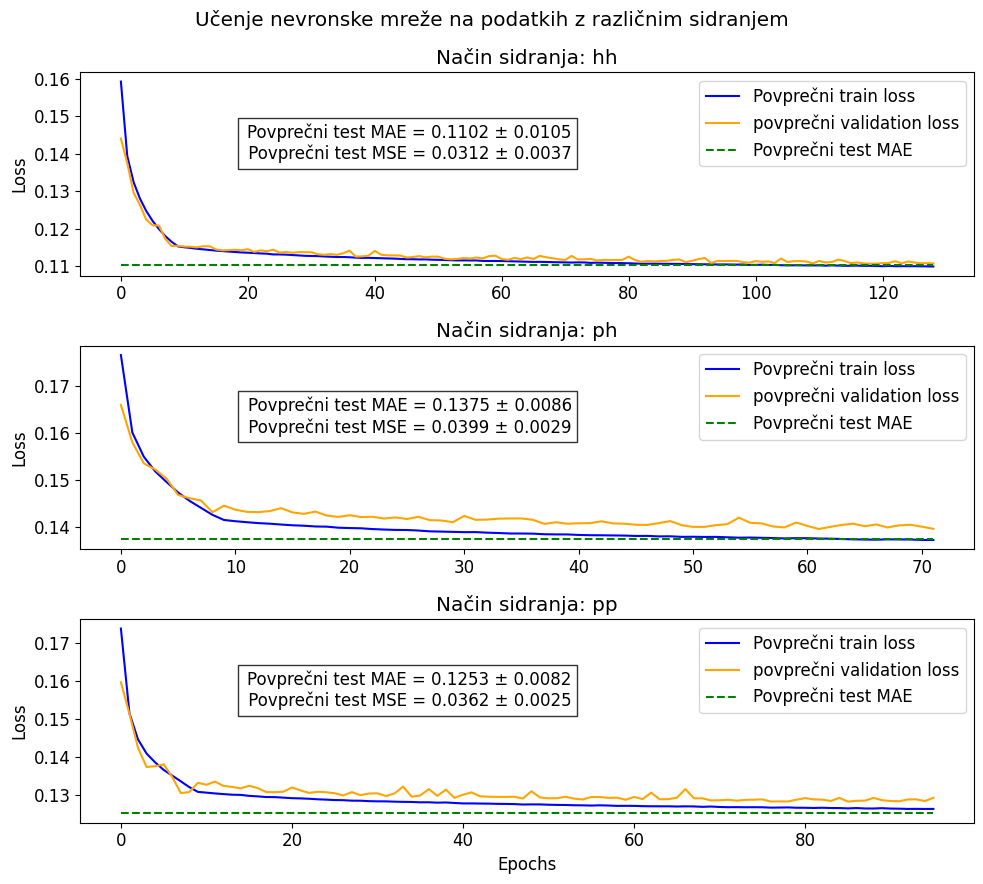

In [40]:
sidranje = ['hh', 'ph', 'pp']
histories_all = [histories0_hh, histories0_ph, histories0_pp]
scores_all = [MAE0_hh, MAE0_ph, MAE0_pp]

MAEs = ["0.1102 ± 0.0105", "0.1375 ± 0.0086", "0.1253 ± 0.0082"]
MSEs = ["0.0312 ± 0.0037", "0.0399 ± 0.0029", "0.0362 ± 0.0025"]

fig, axes = plt.subplots(3, 1, figsize=(10, 9))
fig.suptitle(r'Učenje nevronske mreže na podatkih z različnim sidranjem')
for i, (sid, histories, scores) in enumerate(zip(sidranje, histories_all, scores_all)):
    
    # združi train in val loss vseh fold-ov
    max_epochs = max([len(h.history['loss']) for h in histories])
    train_losses = np.zeros((len(histories), max_epochs))
    val_losses = np.zeros((len(histories), max_epochs))
    
    for j, h in enumerate(histories):
        le = len(h.history['loss'])
        train_losses[j, :le] = h.history['loss']
        val_losses[j, :le] = h.history['val_loss']
        if le < max_epochs:
            # napolni preostanek z zadnjo vrednostjo
            train_losses[j, le:] = h.history['loss'][-1]
            val_losses[j, le:] = h.history['val_loss'][-1]

    # povprečje čez fold-e
    mean_train = np.mean(train_losses, axis=0)
    mean_val = np.mean(val_losses, axis=0)
    
    axes[i].plot(mean_train, label='Povprečni train loss', color='blue')
    axes[i].plot(mean_val, label='povprečni validation loss', color='orange')
    
    # povprečen test MAE čez fold-e
    axes[i].hlines(np.mean(scores), 0, max_epochs-1, colors='green', linestyles='dashed', label='Povprečni test MAE')
    
    # dodaj tekst z MAE in MSE
    text_str = f"Povprečni test MAE = {MAEs[i]}\n Povprečni test MSE = {MSEs[i]}"
    axes[i].text(0.55, 0.75, text_str,
                 transform=axes[i].transAxes,  # koordinate od 0 do 1 v subplotu
                 verticalalignment='top',
                 horizontalalignment='right',
                 bbox=dict(facecolor='white', alpha=0.8))

    axes[i].set_title(f'Način sidranja: {sid}')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

axes[-1].set_xlabel('Epochs')
plt.tight_layout()
plt.show()


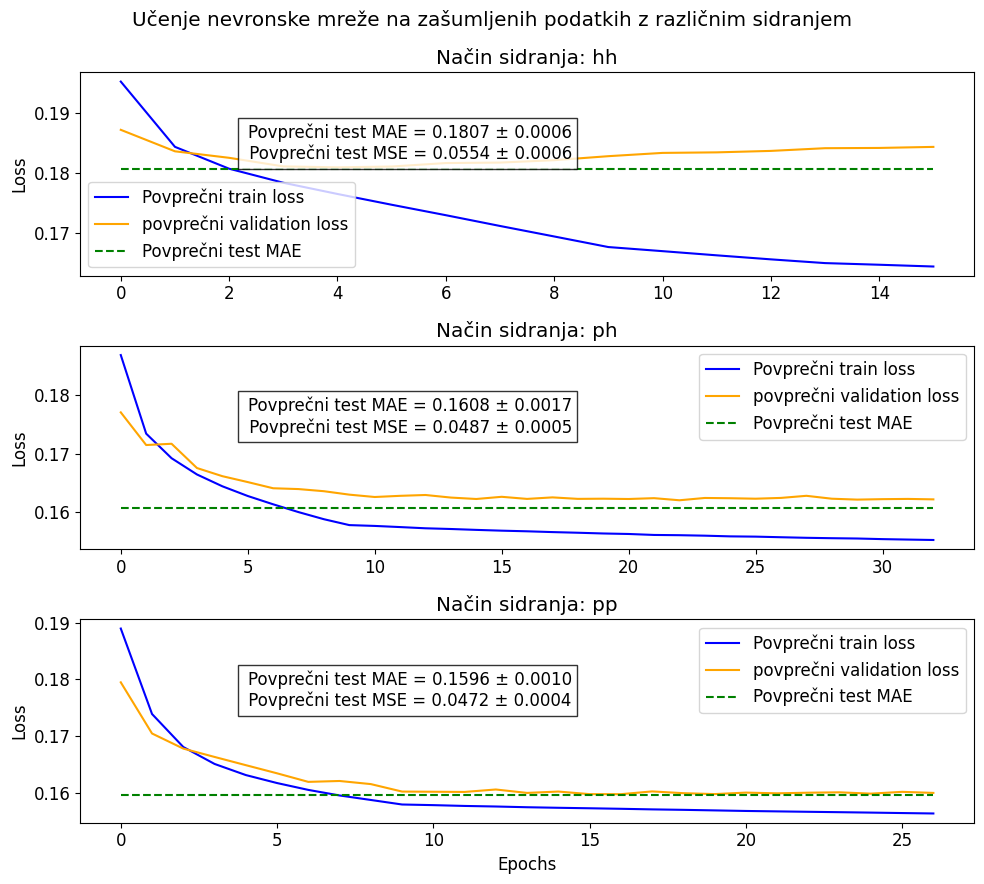

In [43]:
sidranje = ['hh', 'ph', 'pp']
histories_all = [histories100_hh, histories100_ph, histories100_pp]
scores_all = [MAE100_hh, MAE100_ph, MAE100_pp]

MAEs = ["0.1807 ± 0.0006", "0.1608 ± 0.0017", "0.1596 ± 0.0010"]
MSEs = ["0.0554 ± 0.0006", "0.0487 ± 0.0005", "0.0472 ± 0.0004"]

fig, axes = plt.subplots(3, 1, figsize=(10, 9))
fig.suptitle(r'Učenje nevronske mreže na zašumljenih podatkih z različnim sidranjem')
for i, (sid, histories, scores) in enumerate(zip(sidranje, histories_all, scores_all)):
    
    # združi train in val loss vseh fold-ov
    max_epochs = max([len(h.history['loss']) for h in histories])
    train_losses = np.zeros((len(histories), max_epochs))
    val_losses = np.zeros((len(histories), max_epochs))
    
    for j, h in enumerate(histories):
        le = len(h.history['loss'])
        train_losses[j, :le] = h.history['loss']
        val_losses[j, :le] = h.history['val_loss']
        if le < max_epochs:
            # napolni preostanek z zadnjo vrednostjo
            train_losses[j, le:] = h.history['loss'][-1]
            val_losses[j, le:] = h.history['val_loss'][-1]

    # povprečje čez fold-e
    mean_train = np.mean(train_losses, axis=0)
    mean_val = np.mean(val_losses, axis=0)
    
    axes[i].plot(mean_train, label='Povprečni train loss', color='blue')
    axes[i].plot(mean_val, label='povprečni validation loss', color='orange')
    
    # povprečen test MAE čez fold-e
    axes[i].hlines(np.mean(scores), 0, max_epochs-1, colors='green', linestyles='dashed', label='Povprečni test MAE')
    
    # dodaj tekst z MAE in MSE
    text_str = f"Povprečni test MAE = {MAEs[i]}\n Povprečni test MSE = {MSEs[i]}"
    axes[i].text(0.55, 0.75, text_str,
                 transform=axes[i].transAxes,  # koordinate od 0 do 1 v subplotu
                 verticalalignment='top',
                 horizontalalignment='right',
                 bbox=dict(facecolor='white', alpha=0.8))

    axes[i].set_title(f'Način sidranja: {sid}')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

axes[-1].set_xlabel('Epochs')
plt.tight_layout()
plt.show()


- napovedovanje

In [6]:
X0_test_hh = np.load(root + "TestNTrain_hh\\X_test.npy")
X0_test_ph = np.load(root + "TestNTrain_ph\\X_test.npy")
X0_test_pp = np.load(root + "TestNTrain_pp\\X_test.npy")
X100_test_hh = np.load(root + "TestNTrain_hh\\X100_test.npy")
X100_test_ph = np.load(root + "TestNTrain_ph\\X100_test.npy")
X100_test_pp = np.load(root + "TestNTrain_pp\\X100_test.npy")

Y_test_hh = np.load(root + "TestNTrain_hh\\Y_test.npy")
Y_test_ph = np.load(root + "TestNTrain_ph\\Y_test.npy")
Y_test_pp = np.load(root + "TestNTrain_pp\\Y_test.npy")

In [7]:
model0_hh = tf.keras.models.load_model("models3\\model0_hh\\best_model_fold_1.keras")
model0_ph = tf.keras.models.load_model("models3\\model0_ph\\best_model_fold_1.keras")
model0_pp = tf.keras.models.load_model("models3\\model0_pp\\best_model_fold_1.keras")
model100_hh = tf.keras.models.load_model("models3\\model100_hh\\best_model_fold_1.keras")
model100_ph = tf.keras.models.load_model("models3\\model100_ph\\best_model_fold_1.keras")
model100_pp = tf.keras.models.load_model("models3\\model100_pp\\best_model_fold_1.keras")

In [8]:
def accuracy(model, X_test, Y_test, tol):

    Y_pred = model.predict(X_test)

    lower_11 = (1 - tol) * Y_test[:, 0]
    upper_11 = (1 + tol) * Y_test[:, 0]
    lower_33 = (1 - tol) * Y_test[:, 1]
    upper_33 = (1 + tol) * Y_test[:, 1]

    inside_11 = (Y_pred[:, 0] >= lower_11) & (Y_pred[:, 0] <= upper_11)
    inside_33 = (Y_pred[:, 1] >= lower_33) & (Y_pred[:, 1] <= upper_33)

    fraction_inside_11 = np.mean(inside_11)
    fraction_inside_33 = np.mean(inside_33)

    return fraction_inside_11, fraction_inside_33

In [9]:
tol5 = 0.05
tol10 = 0.10

# 0% noise modeli na 0% testu
acc0_0_hh_5   = accuracy(model0_hh, X0_test_hh, Y_test_hh, tol5)
acc0_0_ph_5   = accuracy(model0_ph, X0_test_ph, Y_test_ph, tol5)
acc0_0_pp_5   = accuracy(model0_pp, X0_test_pp, Y_test_pp, tol5)

acc0_0_hh_10  = accuracy(model0_hh, X0_test_hh, Y_test_hh, tol10)
acc0_0_ph_10  = accuracy(model0_ph, X0_test_ph, Y_test_ph, tol10)
acc0_0_pp_10  = accuracy(model0_pp, X0_test_pp, Y_test_pp, tol10)

# 0% noise modeli na 100% testu
acc0_100_hh_5   = accuracy(model0_hh, X100_test_hh, Y_test_hh, tol5)
acc0_100_ph_5   = accuracy(model0_ph, X100_test_ph, Y_test_ph, tol5)
acc0_100_pp_5   = accuracy(model0_pp, X100_test_pp, Y_test_pp, tol5)

acc0_100_hh_10  = accuracy(model0_hh, X100_test_hh, Y_test_hh, tol10)
acc0_100_ph_10  = accuracy(model0_ph, X100_test_ph, Y_test_ph, tol10)
acc0_100_pp_10  = accuracy(model0_pp, X100_test_pp, Y_test_pp, tol10)

# 100% noise modeli na 0% testu
acc100_0_hh_5  = accuracy(model100_hh, X0_test_hh, Y_test_hh, tol5)
acc100_0_ph_5  = accuracy(model100_ph, X0_test_ph, Y_test_ph, tol5)
acc100_0_pp_5  = accuracy(model100_pp, X0_test_pp, Y_test_pp, tol5)

acc100_0_hh_10 = accuracy(model100_hh, X0_test_hh, Y_test_hh, tol10)
acc100_0_ph_10 = accuracy(model100_ph, X0_test_ph, Y_test_ph, tol10)
acc100_0_pp_10 = accuracy(model100_pp, X0_test_pp, Y_test_pp, tol10)

# 100% noise modeli na 100% testu
acc100_100_hh_5  = accuracy(model100_hh, X100_test_hh, Y_test_hh, tol5)
acc100_100_ph_5  = accuracy(model100_ph, X100_test_ph, Y_test_ph, tol5)
acc100_100_pp_5  = accuracy(model100_pp, X100_test_pp, Y_test_pp, tol5)

acc100_100_hh_10 = accuracy(model100_hh, X100_test_hh, Y_test_hh, tol10)
acc100_100_ph_10 = accuracy(model100_ph, X100_test_ph, Y_test_ph, tol10)
acc100_100_pp_10 = accuracy(model100_pp, X100_test_pp, Y_test_pp, tol10)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 734us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 758us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 719us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 702us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 702us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 713us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 695us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 740us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 802us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 742us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 688us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 723us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 766us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 678us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 688us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 721us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 682us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 680us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 689us/step
1250/1250 

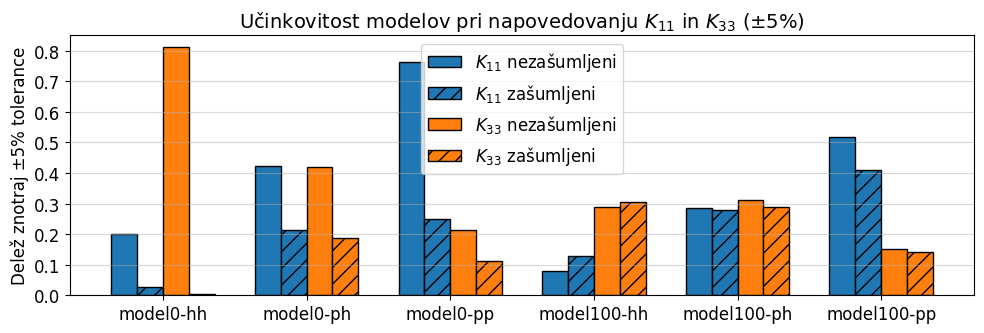

In [124]:
# Pripravimo podatke (samo 5% tolerance)
groups_5 = [
    [acc0_0_hh_10,   acc0_100_hh_10],    # hh, modeli0
    [acc0_0_ph_10,   acc0_100_ph_10],    # ph, modeli0
    [acc0_0_pp_10,   acc0_100_pp_10],    # pp, modeli0
    [acc100_0_hh_10, acc100_100_hh_10],  # hh, modeli100
    [acc100_0_ph_10, acc100_100_ph_10],  # ph, modeli100
    [acc100_0_pp_10, acc100_100_pp_10],  # pp, modeli100
]

# Pretvorimo v obliko 6×4
data = []
for g in groups_5:
    model_0, model_100 = g
    data.append([
        model_0[0],   # C11, model na nenasičenih
        model_100[0], # C11, model na šumnem testu
        model_0[1],   # C33, model na nenasičenih
        model_100[1], # C33, model na šumnem testu
    ])

data = np.array(data)

labels_groups = ["model0-hh", "model0-ph", "model0-pp", "model100-hh", "model100-ph", "model100-pp"]
labels_bars = [r"$K_{11}$ nezašumljeni", r"$K_{11}$ zašumljeni", r"$K_{33}$ nezašumljeni", r"$K_{33}$ zašumljeni"]

N_groups = data.shape[0]
N_bars = data.shape[1]

x = np.arange(N_groups)
width = 0.18

# Barve za dva parametra (C11, C33)
colors = ["tab:blue", "tab:orange"]

# Hachure: clean = nič, noisy = "//"
hatches = ["", "//"]

plt.figure(figsize=(10, 3.5))

for i in range(N_bars):
    # i = 0 → C11 clean
    # i = 1 → C11 noisy
    # i = 2 → C33 clean
    # i = 3 → C33 noisy

    base_color = colors[i // 2]    # C11 = blue, C33 = orange
    hatch = hatches[i % 2]         # clean = "", noisy = "//"

    plt.bar(
        x + (i - 1.5) * width,
        data[:, i],
        width=width,
        label=labels_bars[i],
        color=base_color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x, labels_groups)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylabel("Delež znotraj ±5% tolerance")
plt.title(r"Učinkovitost modelov pri napovedovanju $K_{11}$ in $K_{33}$ (±5%)", fontsize=14)

plt.ylim(0, 0.85)
plt.grid(axis="y", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
time=np.linspace(0,1.95,15600)
print(ts.shape)

(400,)


- Eksperimentalni podatki. Samo ph

(30, 400)


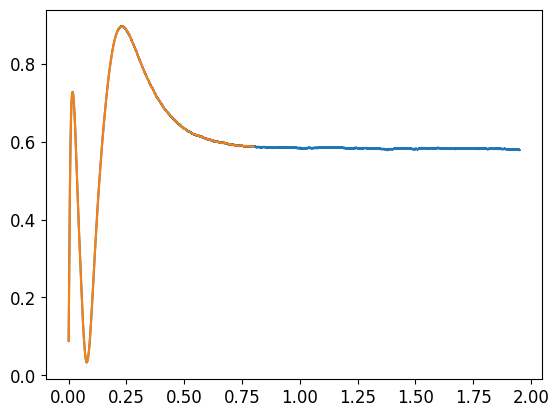

In [58]:
# Eksperimentalni podatki

x_test = np.zeros((30, 400))

for i in range(0, 30):
    x = np.load(root + f"ExpData\\exp_intensity_{i}.npy")
    f = interp1d(time, x, axis=0)
    x_new = f(ts)
    x_test[i] = x_new

print(x_test.shape)

plt.plot(time, x)
plt.plot(ts, x_test[-1])

In [94]:
Kmax = 20e-12
K11 = 6.6e-12
K33 = 9.0e-12
y_test = np.tile([K11, K33], (30, 1))

model100_1 = tf.keras.models.load_model("models3\\model100_ph\\best_model_fold_1.keras")
model100_2 = tf.keras.models.load_model("models3\\model100_ph\\best_model_fold_2.keras")
model100_3 = tf.keras.models.load_model("models3\\model100_ph\\best_model_fold_3.keras")
model100_4 = tf.keras.models.load_model("models3\\model100_ph\\best_model_fold_4.keras")
model100_5 = tf.keras.models.load_model("models3\\model100_ph\\best_model_fold_5.keras")

model0_1 = tf.keras.models.load_model("models3\\model0_ph\\best_model_fold_1.keras")
model0_2 = tf.keras.models.load_model("models3\\model0_ph\\best_model_fold_2.keras")
model0_3 = tf.keras.models.load_model("models3\\model0_ph\\best_model_fold_3.keras")
model0_4 = tf.keras.models.load_model("models3\\model0_ph\\best_model_fold_4.keras")
model0_5 = tf.keras.models.load_model("models3\\model0_ph\\best_model_fold_5.keras")

x_predict100_1 = model100_1.predict(x_test) * Kmax
x_predict100_2 = model100_2.predict(x_test) * Kmax
x_predict100_3 = model100_3.predict(x_test) * Kmax
x_predict100_4 = model100_4.predict(x_test) * Kmax
x_predict100_5 = model100_5.predict(x_test) * Kmax

x_predict0_1 = model0_1.predict(x_test) * Kmax
x_predict0_2 = model0_2.predict(x_test) * Kmax
x_predict0_3 = model0_3.predict(x_test) * Kmax
x_predict0_4 = model0_4.predict(x_test) * Kmax
x_predict0_5 = model0_5.predict(x_test) * Kmax


print(K11, K33)
print(np.average(x_predict100_1, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
6.6e-12 9e-12
[5.8076898e-12 7.3730475e-12]


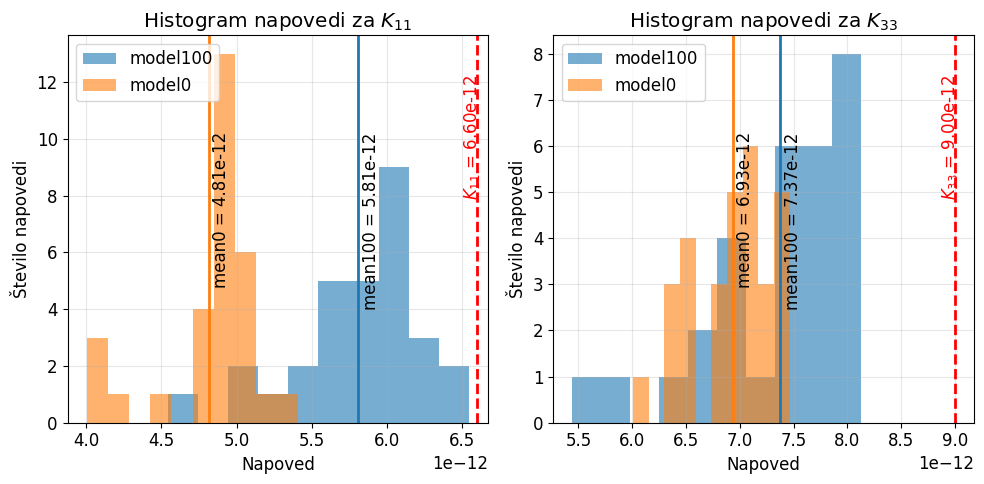

In [120]:
# === Podatki ===
Kmax = 20e-12
K11 = 6.6e-12
K33 = 9.0e-12

# Napovedi (model100_1 in model0_1)
pred100 = x_predict100_1  # shape (30, 2)
pred0   = x_predict0_1    # shape (30, 2)

# === Plot ===
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

labels = [r"$K_{11}$", r"$K_{33}$"]
true_vals = [K11, K33]

colors = {
    "100": "tab:blue",
    "0":   "tab:orange"
}

for i, ax in enumerate(axes):

    # Histogrami modelov
    ax.hist(pred100[:, i], bins=10, alpha=0.6, label="model100",
            density=False, color=colors["100"])
    ax.hist(pred0[:, i], bins=10, alpha=0.6, label="model0",
            density=False, color=colors["0"])

    # === Povprečja porazdelitev ===
    mean100 = np.mean(pred100[:, i])
    mean0   = np.mean(pred0[:, i])

    ax.axvline(mean100, color=colors["100"], linestyle="-", linewidth=2)
    ax.text(mean100*1.005, ax.get_ylim()[1]*0.75,
            f"mean100 = {mean100:.2e}",
            rotation=90, verticalalignment='top',
            color='black')

    ax.axvline(mean0, color=colors["0"], linestyle="-", linewidth=2)
    ax.text(mean0*1.005, ax.get_ylim()[1]*0.75,
            f"mean0 = {mean0:.2e}",
            rotation=90, verticalalignment='top',
            color='black')

    # === Resnična vrednost ===
    ax.axvline(true_vals[i], color="red", linestyle="--", linewidth=2)
    ax.text(0.985*true_vals[i], ax.get_ylim()[1]*0.9,
            f"{labels[i]} = {true_vals[i]:.2e}",
            rotation=90, verticalalignment='top', color="red")

    # Naslov & osi
    ax.set_title(f"Histogram napovedi za {labels[i]}")
    ax.set_xlabel("Napoved")
    ax.set_ylabel("Število napovedi")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


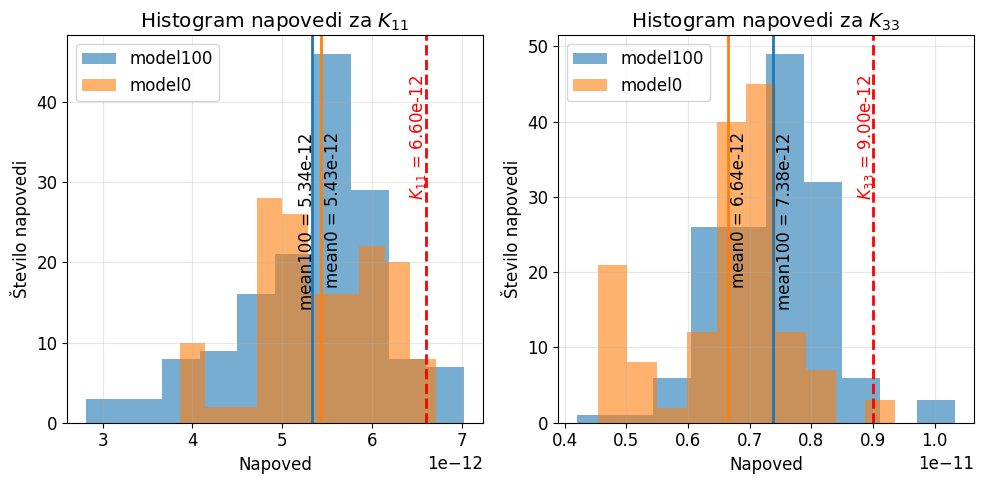

In [123]:
# === Podatki ===
Kmax = 20e-12
K11 = 6.6e-12
K33 = 9.0e-12

# Napovedi (model100_1 in model0_1)
# === Združimo modele (150 × 2) ===
pred100 = np.vstack([
    x_predict100_1,
    x_predict100_2,
    x_predict100_3,
    x_predict100_4,
    x_predict100_5,
])

pred0 = np.vstack([
    x_predict0_1,
    x_predict0_2,
    x_predict0_3,
    x_predict0_4,
    x_predict0_5,
])

# === Plot ===
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

labels = [r"$K_{11}$", r"$K_{33}$"]
true_vals = [K11, K33]

colors = {
    "100": "tab:blue",
    "0":   "tab:orange"
}

for i, ax in enumerate(axes):

    # Histogrami modelov
    ax.hist(pred100[:, i], bins=10, alpha=0.6, label="model100",
            density=False, color=colors["100"])
    ax.hist(pred0[:, i], bins=10, alpha=0.6, label="model0",
            density=False, color=colors["0"])

    # === Povprečja porazdelitev ===
    mean100 = np.mean(pred100[:, i])
    mean0   = np.mean(pred0[:, i])

    ax.axvline(mean100, color=colors["100"], linestyle="-", linewidth=2)
    if i == 0:
        ax.text(mean100*0.97, ax.get_ylim()[1]*0.75,
                f"mean100 = {mean100:.2e}",
                rotation=90, verticalalignment='top',
                color='black')
    else:
        ax.text(mean100*1.006, ax.get_ylim()[1]*0.75,
                f"mean100 = {mean100:.2e}",
                rotation=90, verticalalignment='top',
                color='black')
    ax.axvline(mean0, color=colors["0"], linestyle="-", linewidth=2)
    ax.text(mean0*1.005, ax.get_ylim()[1]*0.75,
            f"mean0 = {mean0:.2e}",
            rotation=90, verticalalignment='top',
            color='black')

    # === Resnična vrednost ===
    ax.axvline(true_vals[i], color="red", linestyle="--", linewidth=2)
    ax.text(0.97*true_vals[i], ax.get_ylim()[1]*0.9,
            f"{labels[i]} = {true_vals[i]:.2e}",
            rotation=90, verticalalignment='top', color="red")

    # Naslov & osi
    ax.set_title(f"Histogram napovedi za {labels[i]}")
    ax.set_xlabel("Napoved")
    ax.set_ylabel("Število napovedi")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()
